# Visualization of capsule data from one experiment

**This script carries out the following tasks:**
1. Loads modules and data for one cell type specified in the first cell ("k562" or "l1210")

2. Embeds the data by carrying out variable gene selection, NMF, and Harmony batch-correction
    - The script also plots number of PCs vs randomized data to establish dimensionality of dataset
    - The script also generates "mock" clonal data by randomly combining cells from day 0

3. Gene-level evidence of persistence:
    - CV vs mean for days 4-6 (sample size-weighted average of within-sample CVs)
    - Gene-gene correlation matrix for the most variable genes

4. Generate UMAP visualizations of variation in the dataset
    - These aren't terribly useful, because the clusters all show heavy re-use of programs

5. NMF factor visualization and analysis of persistence:
    - Heatmap of top gene usage in each NMF program
    - Distribution of colony CVs and fano-factors
    - CV and fano time courses

6. Identifying factors associated with colony size
    - Use a neural network to predict colony size from NMF usage at days 2,4,6, in a manner poorly correlated with day 0.

7. Save (and reload) workspaces

## Loading modules and data

In [1]:
# Allon working in local environment scvi-env
# Python 3.10
# scvi-tools installed with mamba - NOT WORKING
# harmonypy installed with pip install harmonypy

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

import psutil
import sys

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
matplotlib.rcParams['ps.fonttype'] = 42  # Ensures consistency for PostScript files


# Add helper_functions to path
from pathlib import Path
import importlib
helper_path = str(Path().absolute() / 'helper_functions')
if helper_path not in sys.path:
    sys.path.append(helper_path)

# Import my functions specific to this project:
import plotting as hp
# Adding this to allow constant reloads after making changes:
hp = importlib.reload(hp)

import adata_processing as ap
ap = importlib.reload(ap)


raw_dir = './Not_normalized/'
batch_info_file = 'Table_LibraryBatches.xlsx'

cell_type = 'k562' #'k562' 'l1210'
gene_list_file = f'./gene_lists/{cell_type}_gene_list_to_plot.txt'
NMF_list_file = f'./gene_lists/{cell_type}_NMFs_to_plot.txt'
exclude_prefix_file = f'./gene_lists/{cell_type}_exclude_prefix_list.txt'

### Load data

In [2]:
# Load only files with a specific cell type prefix
process = psutil.Process()
print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")

adata_dict = ap.load_h5ad_files(raw_dir)

process = psutil.Process()
print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")


Memory usage: 399.45 MB
Memory usage: 4641.72 MB


In [3]:
sample_info = ap.create_sample_info(adata_dict)
batch_info = ap.read_batch_data(batch_info_file)
sample_info = ap.integrate_batch_data(sample_info, batch_info)

process = psutil.Process()
print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")

Memory usage: 6251.14 MB


In [4]:
# Reduce memory usage
use_keys = sample_info[(sample_info['celltype']==cell_type)
                        ].index
sample_info = sample_info.loc[use_keys,:]
adata_dict = {key:adata_dict[key] for key in list(use_keys)}
gc.collect()

2892

#### Some useful summary stats and plots

In [6]:
print(f"Total number capsules={sample_info['n_cells'].sum()}")

Total number capsules=33657


In [7]:
print(f"Number capsules with single cells (t=0) = {sample_info.loc[sample_info['timepoint']==0,'n_cells'].sum()}")
print(f"Total number capsules with colonies={sample_info.loc[sample_info['timepoint']>0,'n_cells'].sum()}")


Number capsules with single cells (t=0) = 13255
Total number capsules with colonies=20402


## Collate and embed data for analysis

In [6]:
# Collate EVERYTHING for nmf analysis
#use_keys = sample_info[sample_info['timepoint']>0].index
ad_all = ap.unify_adata({k:adata_dict[k] for k in use_keys}, sample_info)
#ap.clean_gene_names_flexible(ad_all) # remove _mm or _hg
process = psutil.Process()
print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")

print('Running NMF and (optional) harmony:')
if cell_type == 'l1210':
    hvg_kwargs = {'n_top_genes': 5000, 'flavor':'seurat_v3','layer':'raw'}
else:
    hvg_kwargs = {'n_top_genes': 4000, 'flavor':'seurat_v3','layer':'raw'}#{'flavor':'seurat','layer':'log'}

NMF_kwargs = {'max_iter': 400, 
              'verbose': 0,
              'alpha_W': 0, # No regularization on usage of programs
              'alpha_H': 0.0, # No regularization
              'l1_ratio': 1.0, 
              'tol': 1e-3,
              'solver': 'cd'
             }
ap = importlib.reload(ap)

ap.run_preprocess_and_harmony(ad_all, num_pcs=15, use_harmony=True, use_NMF=True, 
                              NMF_kwargs=NMF_kwargs, hvg_kwargs = hvg_kwargs)
gc.collect()

# OK, now we sub-sample only the colony data before making a UMAP.
# We'll make a separate UMAP 

# Update condition column:
if np.any(ad_all.obs['condition']=='Ctrl'):
    ad_all.obs['condition_orig'] = ad_all.obs['condition']
    # Create the updated condition values 
    ad_all.obs.loc[ad_all.obs['condition'] == 'Ctrl', 'condition'] = (
        'Ctrl-' + ad_all.obs.loc[ad_all.obs['condition'] == 'Ctrl', 'replicate'].astype(str)
    )

ad_colonies = ad_all[ad_all.obs['timepoint'].astype(int)>0].copy()
ad_sc = ad_all[ad_all.obs['timepoint'].astype(int) == 0].copy()

## NO LONGER REMOVING the full dataset to save memory - keep this for NMF dynamics
#del ad_all
gc.collect()
process = psutil.Process()
print(f"Memory usage: {process.memory_info().rss / 1024 / 1024:.2f} MB")

/opt/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Memory usage: 7544.25 MB
Running NMF and (optional) harmony:


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Memory usage: 9805.50 MB
Running NMF:


/opt/anaconda3/lib/python3.9/site-packages/sklearn/decomposition/_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 400 reached. Increase it to improve convergence.
  warnings.warn(
2025-08-26 23:56:43,117 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


Memory usage: 4577.34 MB


2025-08-26 23:56:45,196 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-26 23:56:45,321 - harmonypy - INFO - Iteration 1 of 30
2025-08-26 23:56:50,517 - harmonypy - INFO - Iteration 2 of 30
2025-08-26 23:56:55,557 - harmonypy - INFO - Iteration 3 of 30
2025-08-26 23:57:01,265 - harmonypy - INFO - Iteration 4 of 30
2025-08-26 23:57:06,529 - harmonypy - INFO - Iteration 5 of 30
2025-08-26 23:57:13,673 - harmonypy - INFO - Iteration 6 of 30
2025-08-26 23:57:20,707 - harmonypy - INFO - Iteration 7 of 30
2025-08-26 23:57:26,107 - harmonypy - INFO - Converged after 7 iterations


Memory usage: 9411.03 MB


#### Evaluate number of factors to use:

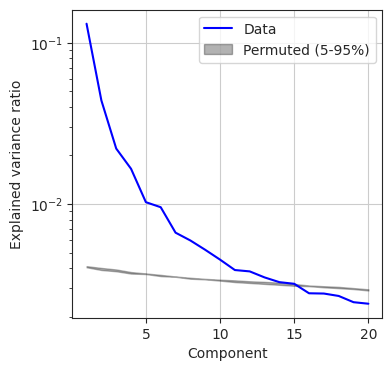

In [7]:
ap = importlib.reload(ap)

# real_var: A 1D array of length n_components containing the explained variance ratio 
# for each component in our data (ad_all[:, adata.var.highly_variable].X). 
# Each value represents what fraction of total variance that the component explains.
#
# perm_vars: A 2D array of shape (n_permutations, n_components) containing the explained
# variance ratios for permuted data. Each row represents one permutation's results.

real_var, perm_vars = ap.compare_variance_explained(ad_all, n_components=20, sample_frac=0.1, n_permutations=5)


plt.figure(figsize=(4, 4))
plt.plot(range(1, len(real_var) + 1), real_var, 'b-', label='Data')
plt.fill_between(range(1, len(real_var) + 1), 
                np.percentile(perm_vars, 5, axis=0),
                np.percentile(perm_vars, 95, axis=0),
                color='k', alpha=0.3, label='Permuted (5-95%)')
plt.xlabel('Component')
plt.ylabel('Explained variance ratio')
plt.yscale('log')
plt.legend()
plt.grid(True)

#### Evaluate NMF factor 'quality'

In [ ]:
# # A high-quality factor would:
# # * have more genes contributing at a high level. By contrast, if one gene dominates then the factor is lower quality.
# # * the genes that contribute the most are also contributing little to other factors. By contrast, some factors share genes with other factors.

# ap = importlib.reload(ap)



# NMF_quality, NMF_uniqueness = ap.evaluate_factor_quality(ad_all, ad_all.uns['nmf']['components'])


In [9]:
# Let's save mean of the genes conditional on being non-zero::

X_hvg = ad_all[:, ad_all.var.highly_variable].X.toarray()
nonzero_means = X_hvg.mean(axis=0)/(1-np.sum(X_hvg == 0, axis=0)/X_hvg.shape[0])
ad_all.var['mean_nonzero'] = np.nan
ad_all.var.loc[ad_all.var.highly_variable, 'mean_nonzero'] = nonzero_means


### Generate mock clonal data

In [16]:
# Prepare random permutation of single cell usages:
ap = importlib.reload(ap)

timepoint_ns = {2: 4, 4: 16, 6: 64} # Approximating 1 division per day - low

ad_colonies_rand = ap.create_count_based_clones(ad_sc, ad_all.obs, timepoint_ns)

/Users/allon/miniconda3/envs/scvi-env/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/allon/miniconda3/envs/scvi-env/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/allon/miniconda3/envs/scvi-env/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


## Gene-wise analyses:

### Plot gene-wise CV vs mean for real vs mock data

In [18]:
ap = importlib.reload(ap)

gene_cv_mean_dict = ap.get_gene_cv_mean_dataframes(ad_all)
rnd_gene_cv_mean_dict = ap.get_gene_cv_mean_dataframes(ad_colonies_rand)

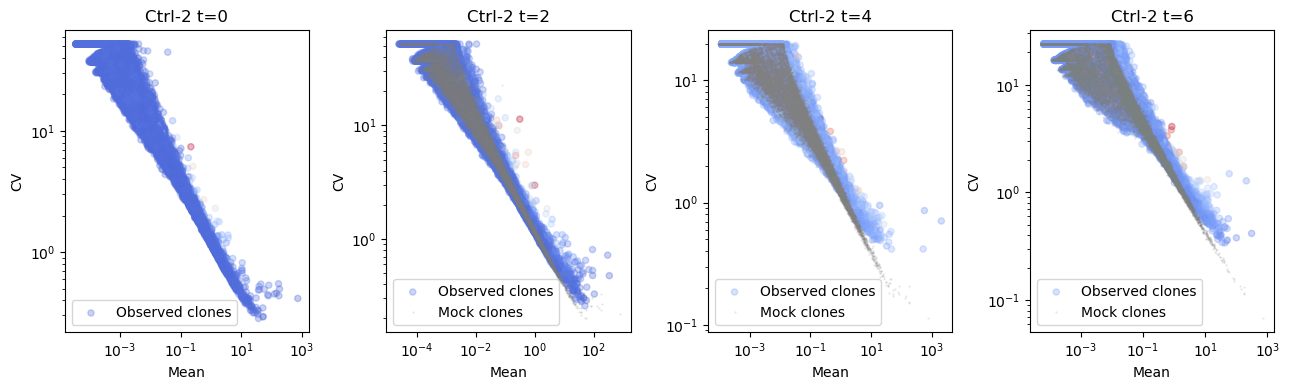

In [19]:
# Imports (if not already imported)
import matplotlib.pyplot as plt
hp = importlib.reload(hp)
c = 'Ctrl-2'
fig = hp.plot_gene_cv_vs_mean(ad_all, gene_cv_mean_dict, rnd_gene_cv_mean_dict, c)
    
plt.show()

/Users/allon/HMS Dropbox/Allon Klein/Shared_Ignas/Paper - Capsules/Figure_drafts/Data_and_plots/Memory_Seq/helper_functions/plotting.py:1131: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby(['condition', 'timepoint']).size()
/Users/allon/HMS Dropbox/Allon Klein/Shared_Ignas/Paper - Capsules/Figure_drafts/Data_and_plots/Memory_Seq/helper_functions/plotting.py:1165: RuntimeWarning: invalid value encountered in divide
  mean_cvs = np.sqrt(mean_vars) / mean_means


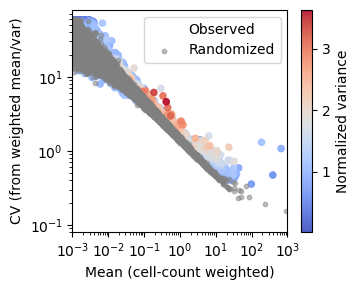

In [20]:
hp = importlib.reload(hp)
use_cond = ['Ctrl-1','Ctrl-2','Ctrl-3']
fig,ax = hp.plot_weighted_cv_vs_mean(gene_cv_mean_dict,rnd_gene_cv_mean_dict, ad_all, conditions=use_cond, timepoints=[4,6])
ax.set_xlim(1e-3, 1e3)

hp.save_figure_rasterized_data(fig, 
    f'./figures/CV_vs_mean_plots/fig_cv_mean_{cell_type}_Day4-6_Ctrl.pdf', 
    dpi=300)
plt.show()


### Gene-gene correlation cluster plot

In [5]:
hp = importlib.reload(hp)

use_cond = ['Ctrl-1','Ctrl-2','Ctrl-3']
exclude_prefix_file = f'./gene_lists/{cell_type}_exclude_prefix_list.txt'
exclude_suffix_file = f'./gene_lists/{cell_type}_exclude_suffix_list.txt'

fig, ordered_corr, ordered_genes = hp.plot_weighted_gene_correlations(gene_cv_mean_dict,
        ad_all, conditions=use_cond, timepoints=[4,6], 
        n_top_genes=150, vmin=-0.2, vmax=0.2,
        exclude_prefix_file=exclude_prefix_file, 
        exclude_suffix_file=None,
        clustering_method='average',  # Try 'ward', 'complete', or 'average'
        min_corr_threshold=None  # e.g., 0.3 to focus on stronger correlations
        )
#hp.save_figure_rasterized_data(fig, 
#    f'./figures/gene_gene_corr/fig_top150genes_wtd_mean_corr{cell_type}_Day4-6_Ctrl.pdf', 
#    dpi=300)
#plt.show()


AttributeError: module 'plotting' has no attribute 'plot_weighted_gene_correlations'

### Differential gene expression analysis

In [51]:
ap = importlib.reload(ap)
control_dict = {'Vor': 'Ctrl', 'Dec': 'Ctrl', 'Aza': 'Ctrl'}
drugs = ['Vor','Dec','Aza']

deg_results_dict = ap.differential_expression_analysis(ad_colonies, control_dict, timepoints=[6], drugs=drugs)

# Save results to file for plotting later
# Save differential expression results using pickle
with open(f'./Table S2 sheets/{cell_type}_deg_results_dict.pkl', 'wb') as f:
    pickle.dump(deg_results_dict, f)


Analyzing Vor, time point 6 days:
Calculating mean expression...
Calculating rank-sum p-values...
Calculating weighted means and log fold change...
Combining p-values using Fisher's method...


/Users/allon/miniconda3/envs/scvi-env/lib/python3.10/site-packages/scipy/stats/_stats_py.py:9694: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * np.sum(np.log(pvalues))


Analyzing Dec, time point 6 days:
Calculating mean expression...
Calculating rank-sum p-values...
Calculating weighted means and log fold change...
Combining p-values using Fisher's method...
Analyzing Aza, time point 6 days:
Calculating mean expression...
Calculating rank-sum p-values...
Calculating weighted means and log fold change...
Combining p-values using Fisher's method...


## UMAP data visualization:

### UMAP embed and explore colony data:

In [22]:
print('Running UMAP:')
sc.pp.neighbors(ad_colonies, use_rep='X_pca_harmony',n_neighbors=10)
sc.tl.leiden(ad_colonies,resolution=0.5)
sc.tl.umap(ad_colonies, neighbors_key='neighbors') 

Running UMAP:


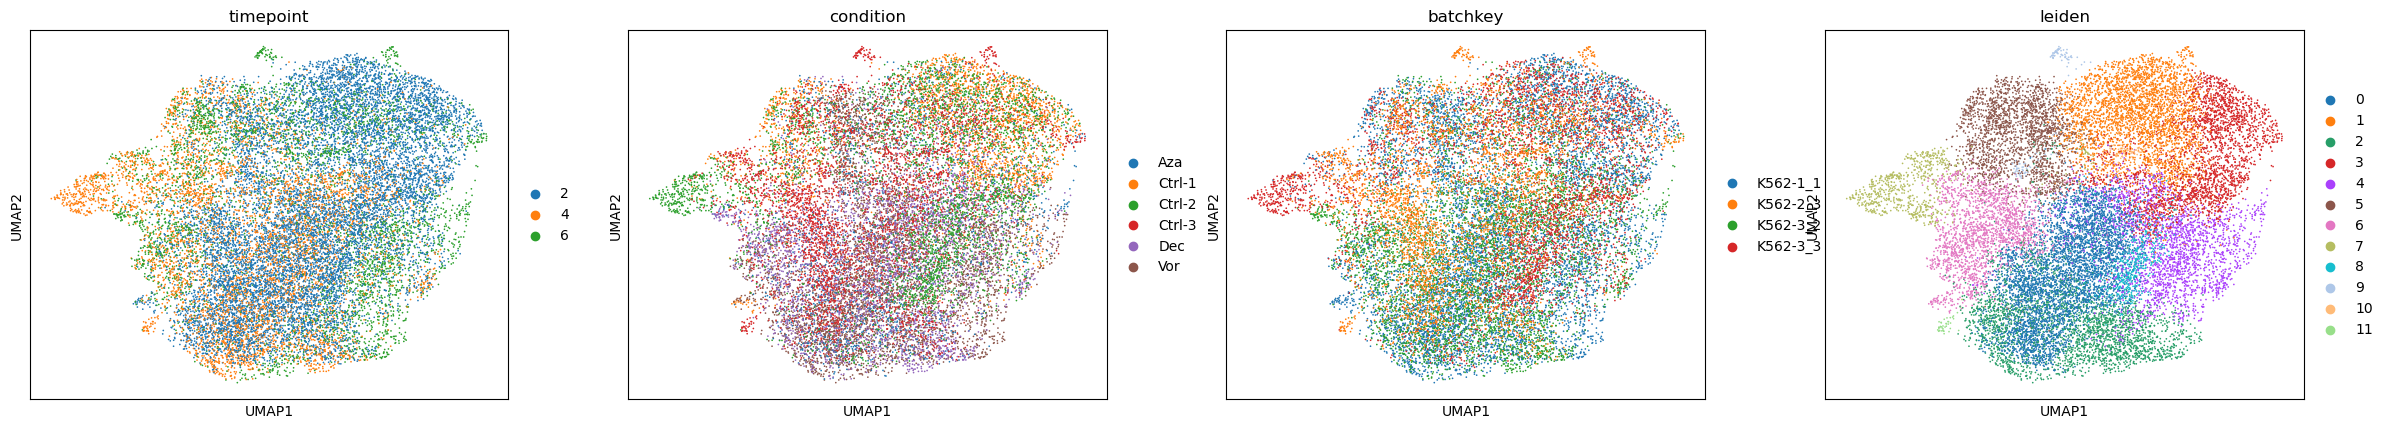

In [24]:
sc.pl.umap(ad_colonies, color=['timepoint','condition','batchkey','leiden'],show=False)
plt.show()

/var/folders/rv/y54x08qj7wqb3c4s6_wk8c7w0000gr/T/ipykernel_40879/2092685680.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_nmf_mean = pd_nmf.groupby('leiden').mean().T


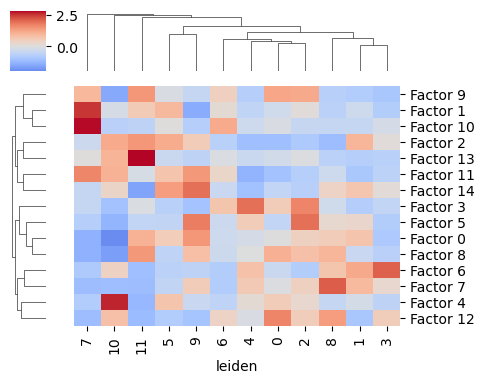

In [26]:
# Plot NMF factor usage over clusters
# Create a DataFrame of NMF factors
pd_nmf = pd.DataFrame(
    ad_colonies.obsm['X_nmf'],
    columns=[f'Factor {f}' for f in range(15)],
    index=ad_colonies.obs_names  # Add index for better data tracking
)

# Add leiden clusters
pd_nmf['leiden'] = ad_colonies.obs['leiden']

# Calculate mean per leiden cluster
pd_nmf_mean = pd_nmf.groupby('leiden').mean().T

# Create clustermap with enhanced visualization
fig = sns.clustermap(
    pd_nmf_mean,
    cmap='coolwarm',  # Diverging colormap, good for showing positive/negative values
    center=0,       # Center colormap at 0
    figsize=(5, 4),
    dendrogram_ratio=(.1, .2),  # Adjust dendrogram size
    cbar_pos=(0.02, 0.8, 0.05, 0.18),  # Adjust colorbar position
    yticklabels=True,
    xticklabels=True,
    z_score=0
)

# Rotate x-axis labels for better readability
plt.setp(fig.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, ha='center')

# Optional: Adjust layout to prevent label cutoff
plt.tight_layout()

### Generate publication quality plots - for colonies

In [28]:

# Randomize the data to avoid plotting order mattering
sc.pp.subsample(ad_colonies, fraction=1., copy=False)

In [29]:

hp.save_umaps(ad_colonies,['timepoint', 'condition','batchkey','leiden','batchkey'],
              prefix=f'umap_harmony_{cell_type}_colonies_',
              save_folder='./figures/nmf_umaps_colonies/', 
              umap_kwargs={'alpha':0.6, 'size':30, 'sort_order':False},
              )
                        

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [31]:
gene_list = pd.read_csv(gene_list_file, header=None)[0].tolist()
hp.save_umaps(ad_colonies, gene_list,
              prefix=f'umap_harmony_{cell_type}_colonies_',
              save_folder='./figures/nmf_umaps_colonies/', 
              umap_kwargs={ 'size':30, 'sort_order':True,
                           'cmap':'magma','vmin':0,'vmax':'p99'},
              )
                        

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

### UMAP embed and make plots single cell data:

In [33]:
print('Running UMAP:')
sc.pp.neighbors(ad_sc, use_rep='X_pca_harmony',n_neighbors=10)
sc.tl.umap(ad_sc, neighbors_key='neighbors') 


Running UMAP:


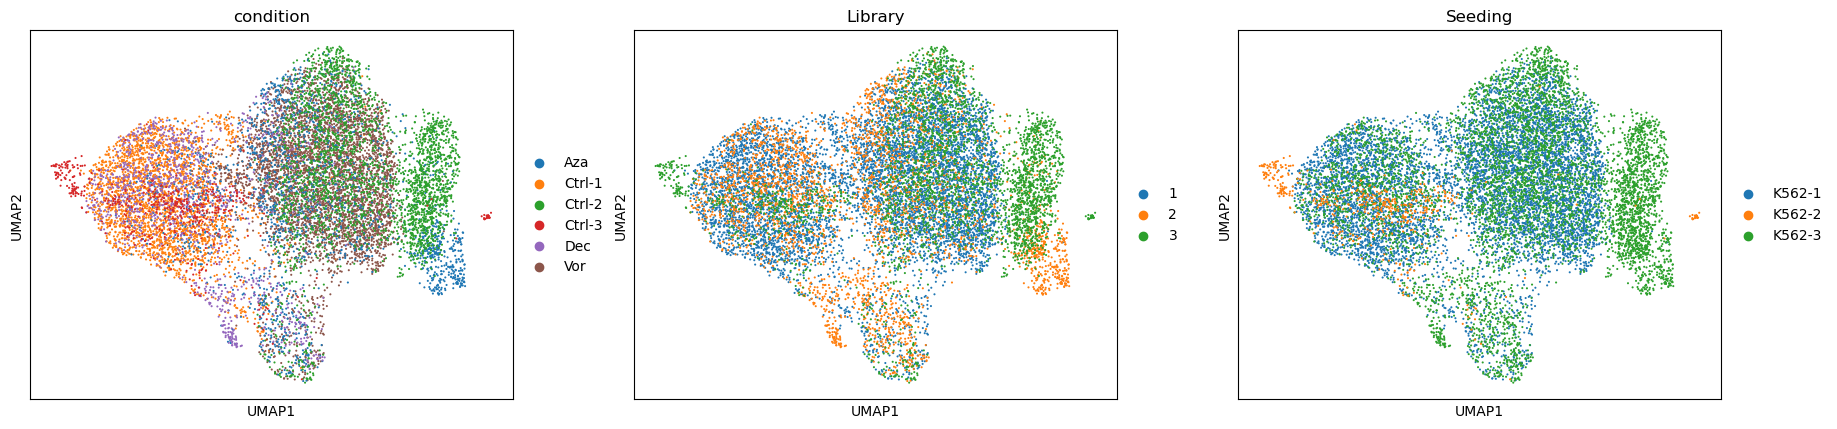

In [34]:
sc.pl.umap(ad_sc, color=['condition','Library', 'Seeding'])


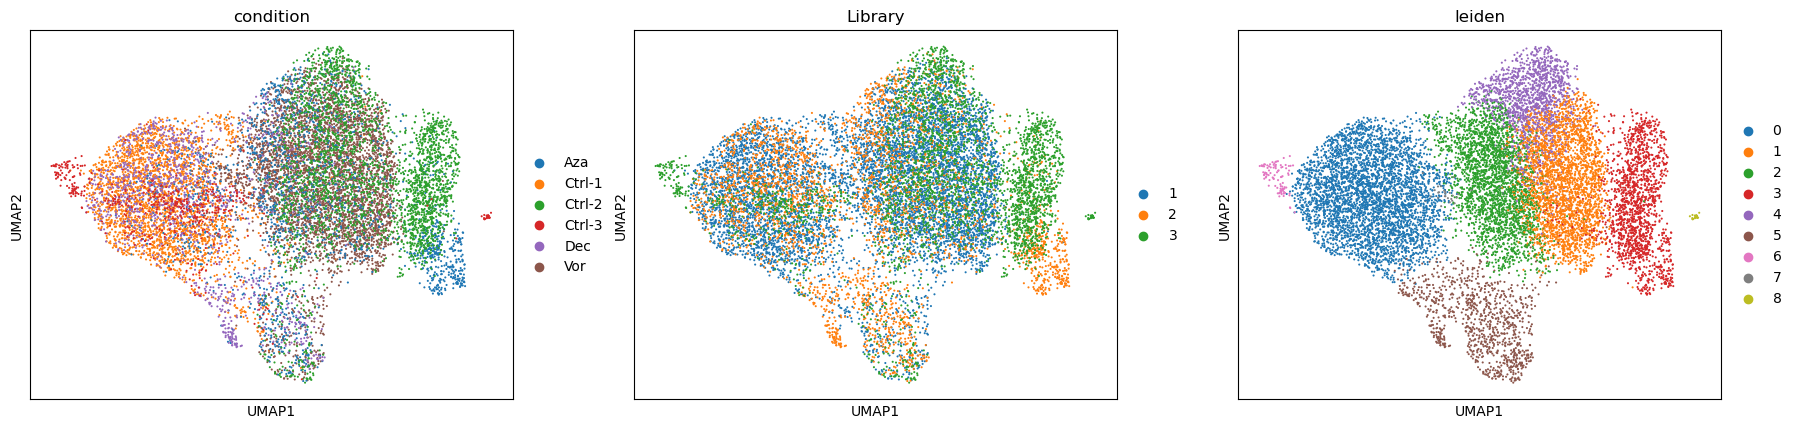

In [36]:
sc.pl.umap(ad_sc, color=['condition','Library','leiden'],show=False)
plt.show()

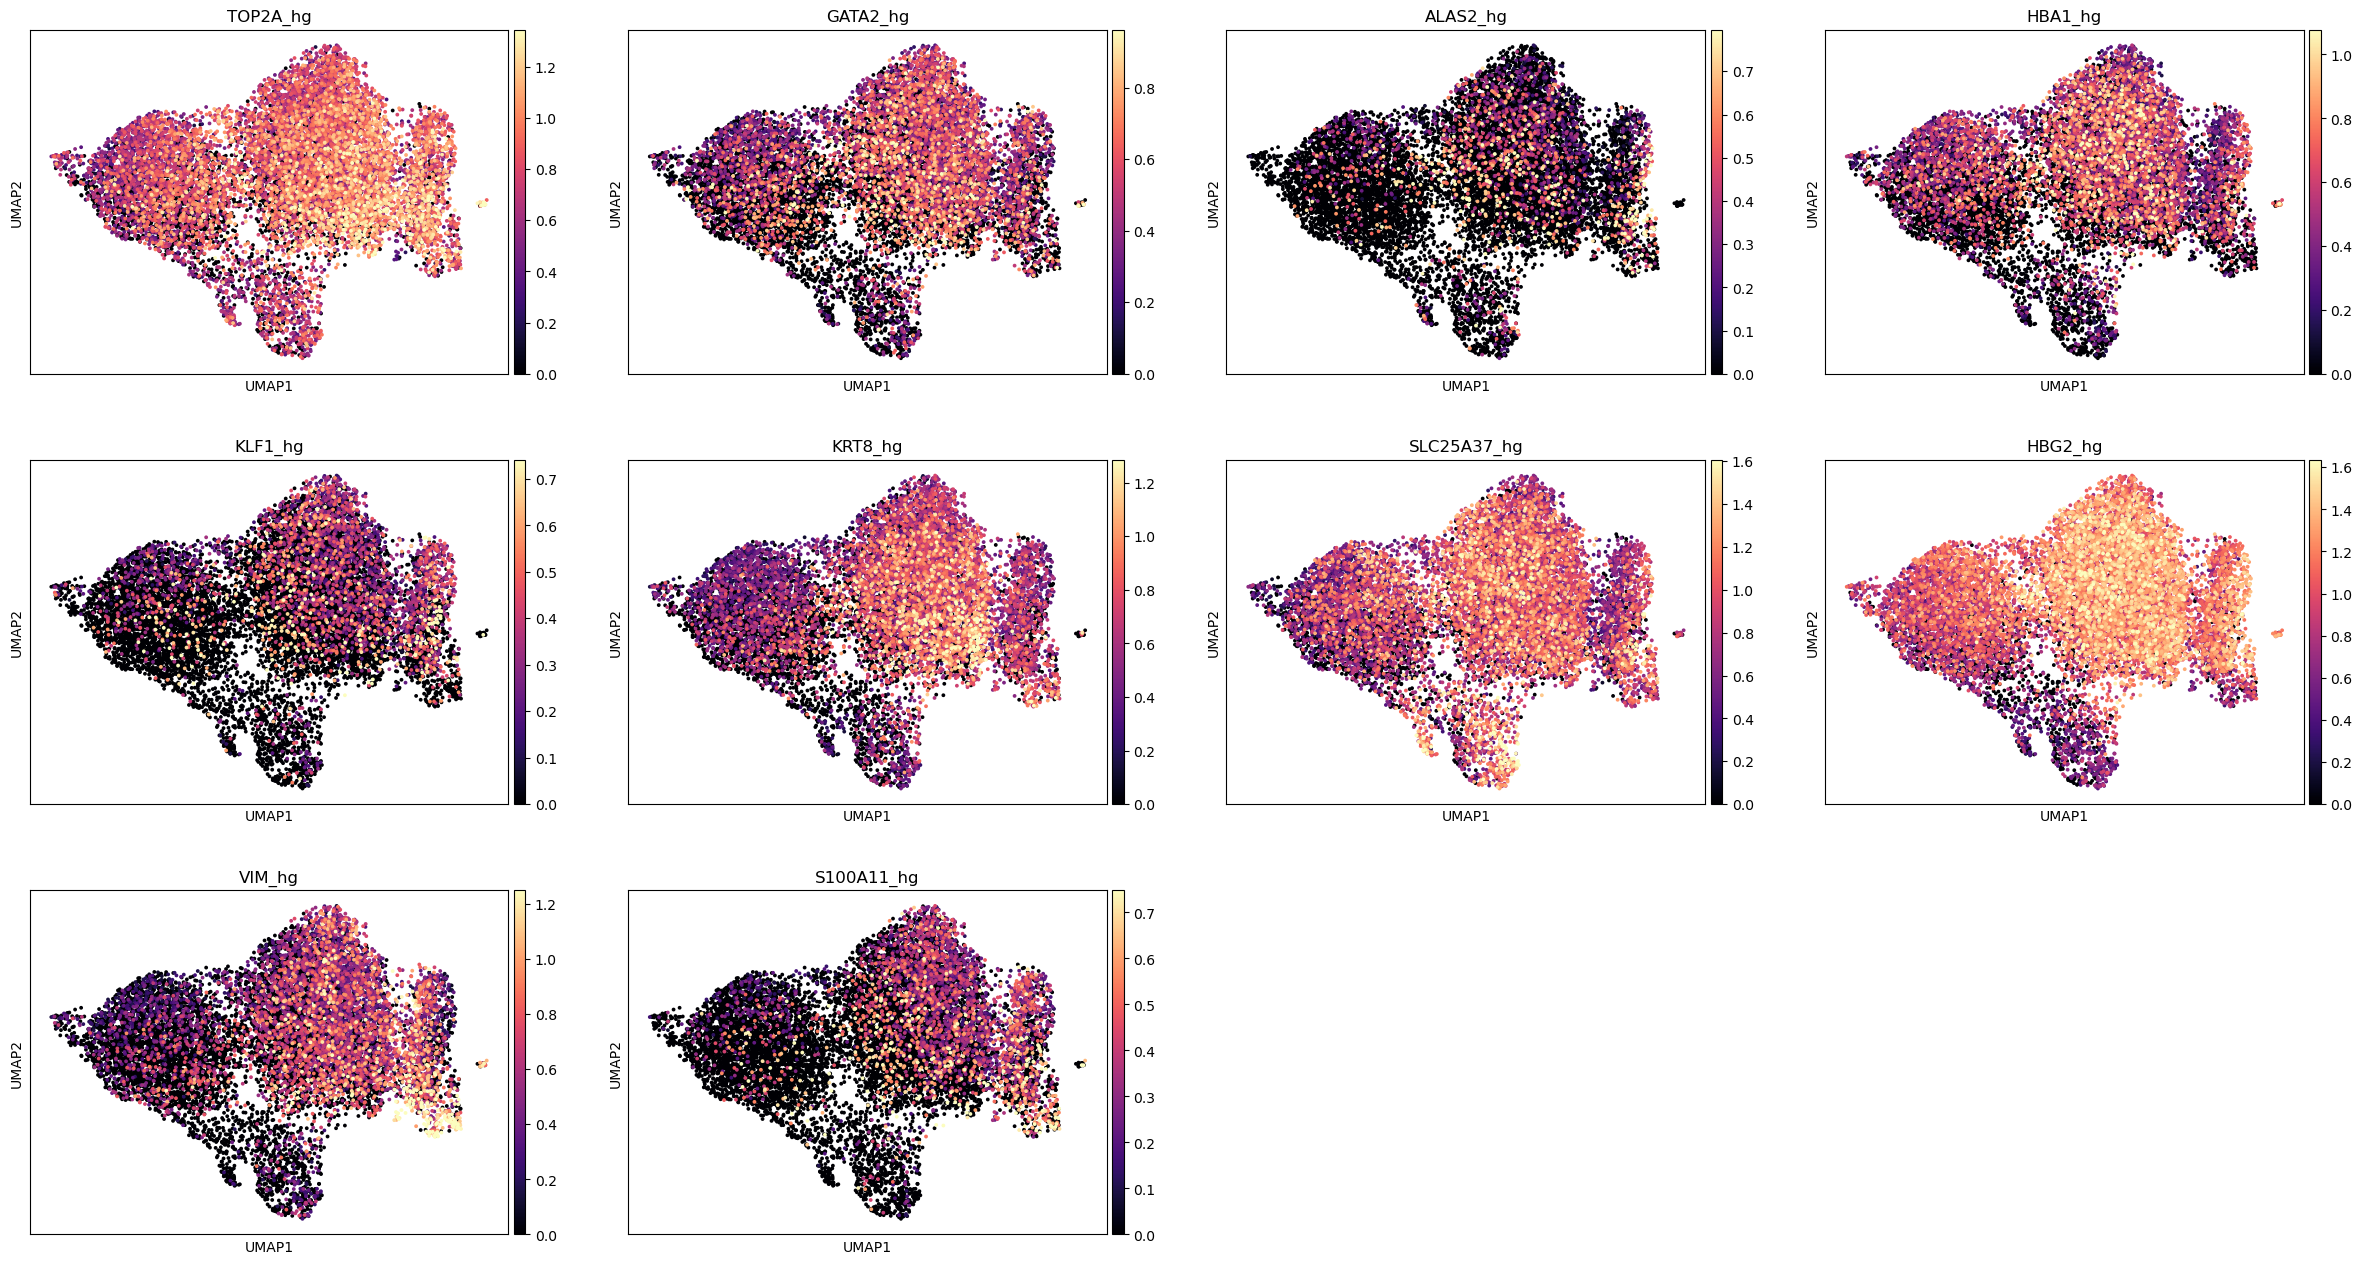

In [37]:
sc.pl.umap(ad_sc, color=gene_list,cmap='magma',vmin=0,vmax='p99',s=30,show=False)
plt.show()


/var/folders/rv/y54x08qj7wqb3c4s6_wk8c7w0000gr/T/ipykernel_40879/1628430942.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_nmf_mean = pd_nmf.groupby('leiden').mean().T


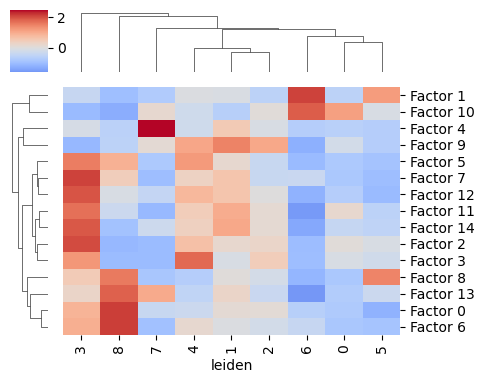

In [38]:
# Plot NMF factor usage over clusters
# Create a DataFrame of NMF factors
pd_nmf = pd.DataFrame(
    ad_sc.obsm['X_nmf'],
    columns=[f'Factor {f}' for f in range(15)],
    index=ad_sc.obs_names  # Add index for better data tracking
)

# Add leiden clusters
pd_nmf['leiden'] = ad_sc.obs['leiden']

# Calculate mean per leiden cluster
pd_nmf_mean = pd_nmf.groupby('leiden').mean().T

# Create clustermap with enhanced visualization
fig = sns.clustermap(
    pd_nmf_mean,
    cmap='coolwarm',  # Diverging colormap, good for showing positive/negative values
    center=0,       # Center colormap at 0
    figsize=(5, 4),
    dendrogram_ratio=(.1, .2),  # Adjust dendrogram size
    cbar_pos=(0.02, 0.8, 0.05, 0.18),  # Adjust colorbar position
    yticklabels=True,
    xticklabels=True,
    z_score=0
)

# Rotate x-axis labels for better readability
plt.setp(fig.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, ha='center')

# Optional: Adjust layout to prevent label cutoff
plt.tight_layout()

### Generate publication quality plots - for single cells

In [40]:

# Randomize the data to avoid plotting order mattering
sc.pp.subsample(ad_sc, fraction=1., copy=False)

In [41]:

hp.save_umaps(ad_sc,['timepoint', 'condition','batchkey','leiden','batchkey'],
              prefix=f'umap_harmony_{cell_type}_sc_',
              save_folder='./figures/nmf_umaps_single_cells/', 
              umap_kwargs={'alpha':0.6, 'size':30, 'sort_order':False},
              )
                        

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [42]:
hp.save_umaps(ad_sc, gene_list,
              prefix=f'umap_harmony_{cell_type}_sc_',
              save_folder='./figures/singlecell_nmf_umaps/', 
              umap_kwargs={ 'size':30, 'sort_order':True,
                           'cmap':'magma','vmin':0,'vmax':'p99'},
              )
                        

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

## NMF factor analyses:

### Generate NMF factor usage heatmap

In [9]:
# Import my functions specific to this project:
import plotting as hp
# Adding this to allow constant reloads after making changes:
hp = importlib.reload(hp)

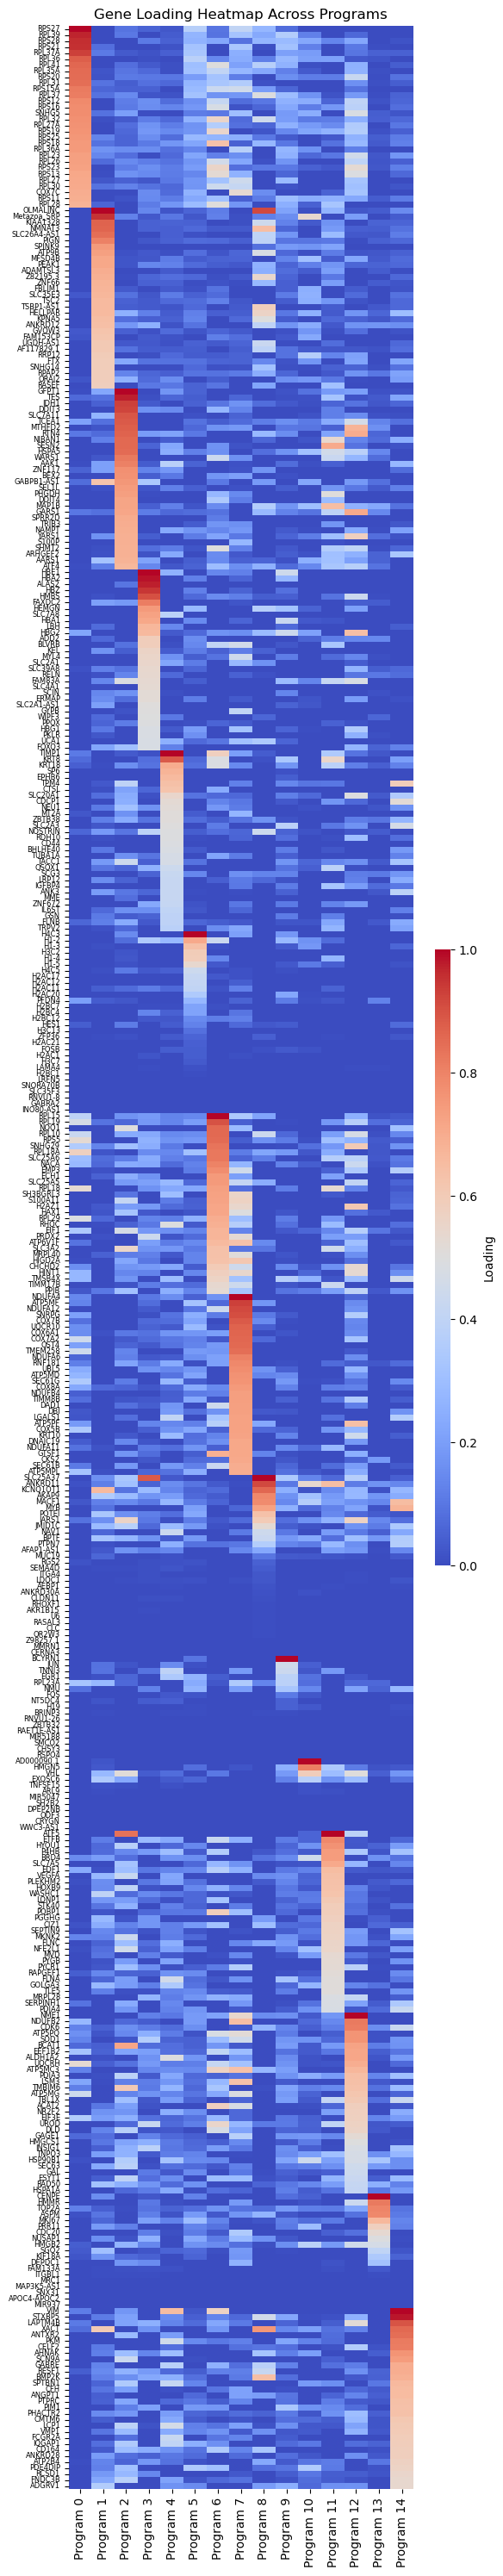

In [15]:
gene_names = ad_colonies.uns['nmf']['highly_variable_genes']
gene_names = [gene[:-3] if gene.endswith('_mm') else gene for gene in gene_names]
gene_names = [gene[:-3] if gene.endswith('_hg') else gene for gene in gene_names]
H = ad_colonies.uns['nmf']['components']
# Reweight by non-zero mean expression:
nonzero_means = ad_all.var.loc[ad_all.var.highly_variable, 'mean_nonzero'].values  # Add .values
H = H / nonzero_means[None, :] 
#H_norm = H_weighted / (H_weighted.sum(axis=0) + 1e-10)
# Create a boolean mask for non-mitochondrial genes
do_filter_genes = True
if do_filter_genes:
    exclude_prefixes = pd.read_csv(exclude_prefix_file, header=None)[0].tolist()
    exclude_suffixes = ['Rik']
    mask = ~np.array([any(gene.startswith(p) for p in exclude_prefixes)
                      for gene in gene_names])
    mask = mask & ~np.array([any(gene.endswith(p) for p in exclude_suffixes)
                      for gene in gene_names])
    # Apply the mask to both the array and gene list
    H = H[:,mask]
    gene_names = np.array(gene_names)[mask]


n=ad_colonies.uns['nmf']['n_components']
H = H/H.max(axis=1,keepdims=True) # Col-normalize to the gene with highest contribution
#H = H/H.sum(axis=1,keepdims=True)
#H = H/H.max(axis=0,keepdims=True) # Row-normalize
fig=hp.plot_nmf_programs_heatmap(H, gene_names, range(15), n_genes=30, figsize=(6, 30))
#plt.savefig(f'{cell_type}_all_nmf_factors_n={n}.pdf')
hp.save_figure_rasterized_data(fig, 
                               f'./figures/NMF_programs/fig_{cell_type}_all_nmf_factors_n={n}.pdf', 
                               dpi=300)

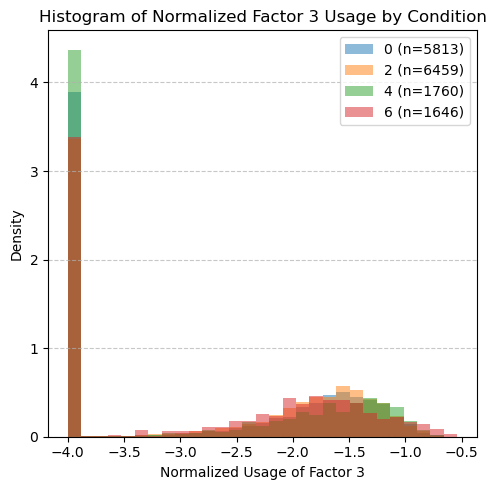

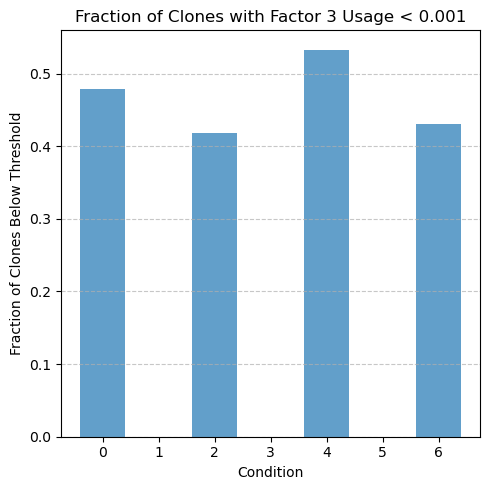

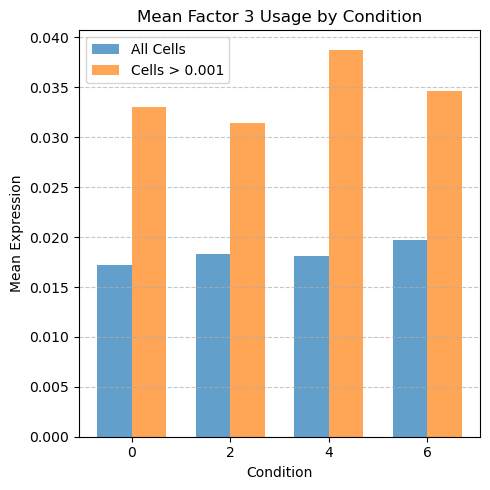

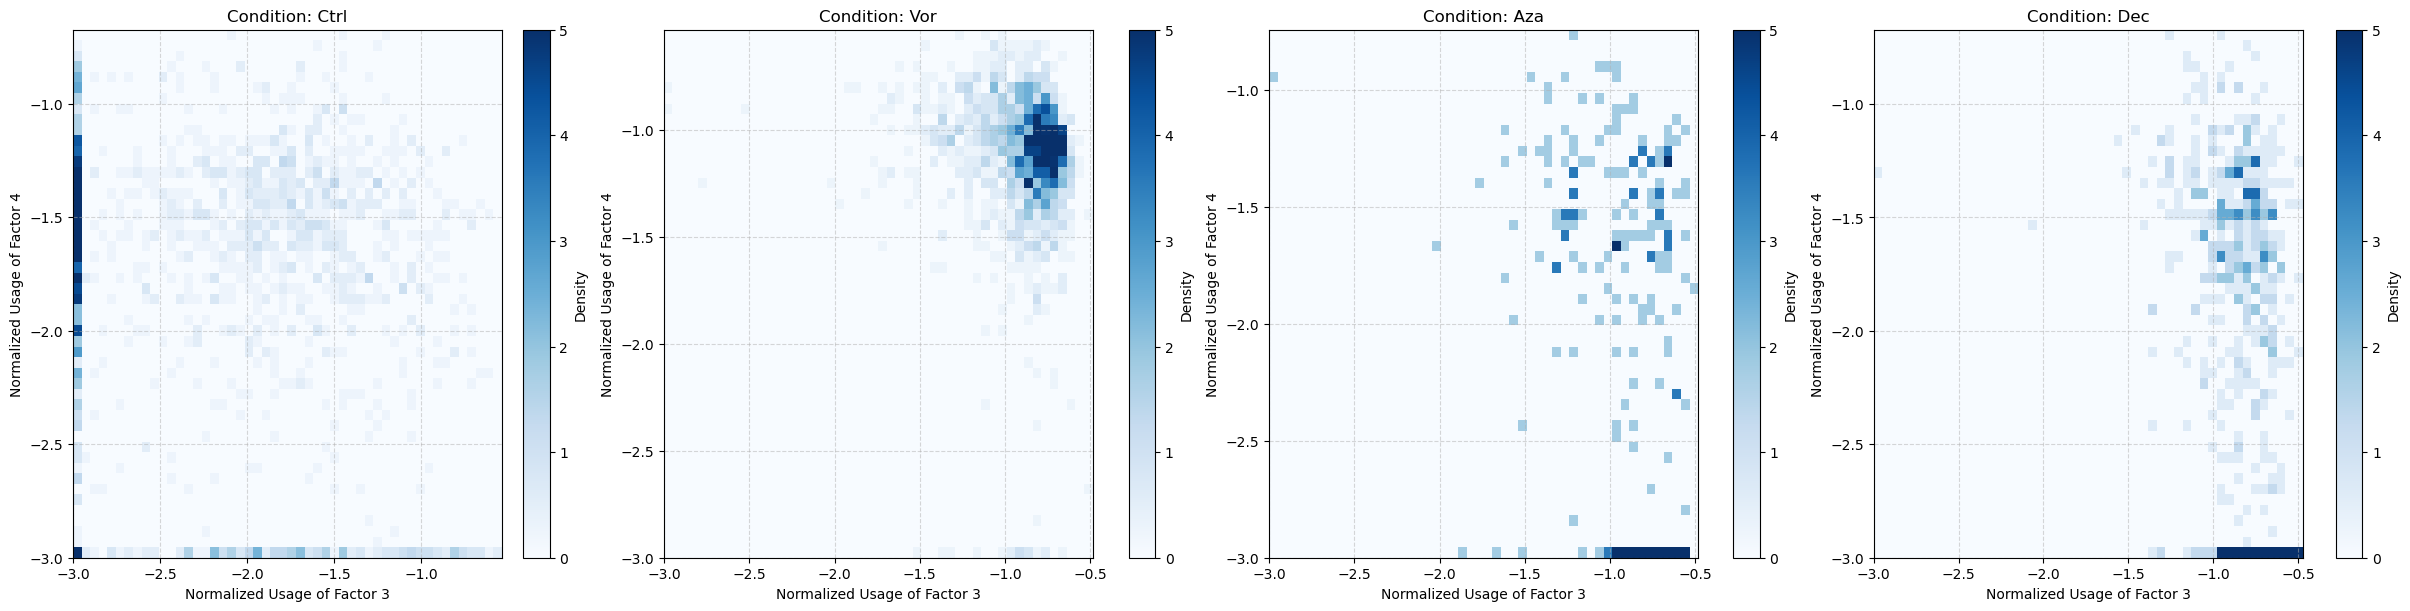

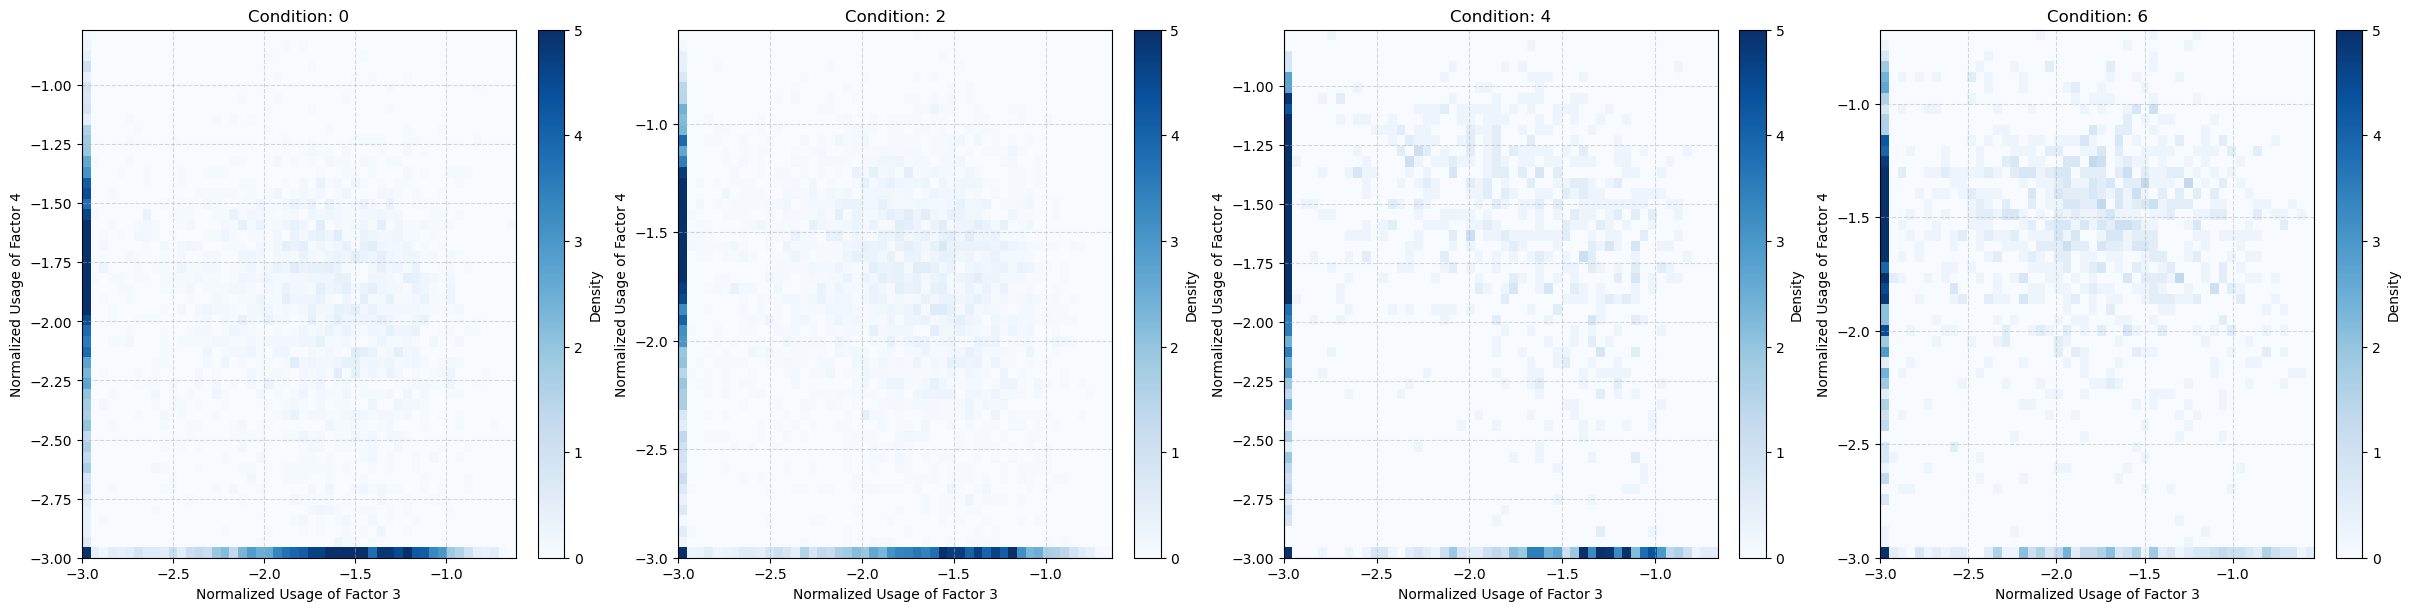

In [ ]:
# hp = importlib.reload(hp)
# cond = 'Ctrl'
# factor = 3


# fig1 = hp.plot_nmf_factor_histogram(ad_all, factor,'timepoint',
#             filter_column='condition_orig', filter_value=cond ,use_log=True, pseudocount=1e-4)
# fig2= hp.plot_fraction_factor_below_threshold(ad_all, factor, 'timepoint',
#             0.001, filter_column='condition_orig', filter_value=cond)
# fig3= hp.plot_mean_factor_expression(ad_all, factor, 'timepoint', 
#             0.001, filter_column='condition_orig', filter_value=cond)

# fig=hp.plot_nmf_factor_2Dhistogram(ad_all, 3, 4, 'condition_orig', 
#                             filter_column='timepoint', filter_value=6, use_log=True,
#                             cap_density_value=5)

# fig=hp.plot_nmf_factor_2Dhistogram(ad_all, 3, 4, 'timepoint', 
#                             filter_column='condition_orig', filter_value=cond, use_log=True,
#                             cap_density_value=5)


In [ ]:
# ap = importlib.reload(ap)
# ap.find_similar_genes(gene_names, 'Ccnb2_mm')

AttributeError: module 'adata_processing' has no attribute 'find_similar_genes'

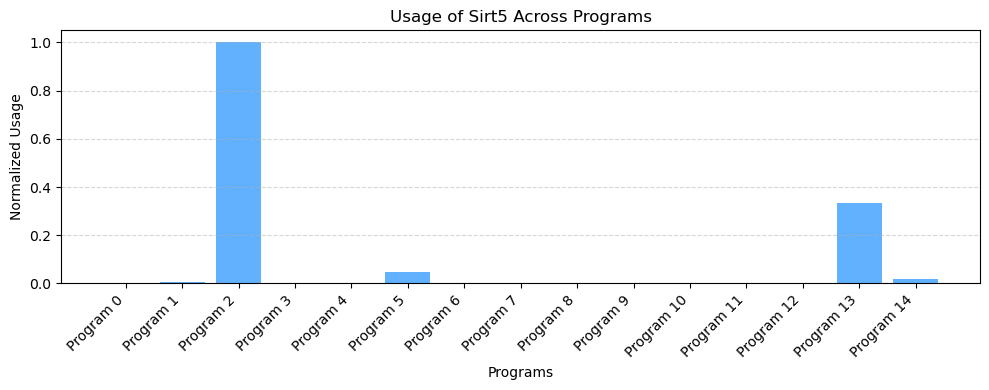

In [ ]:
# hp = importlib.reload(hp)


# hp.plot_gene_usage(H, gene_names, "Sirt5")

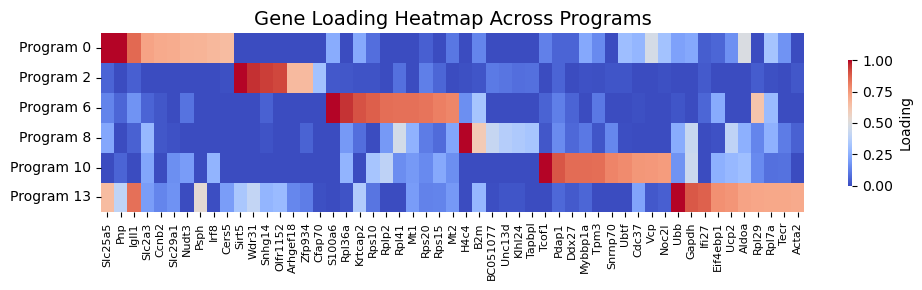

In [51]:
hp = importlib.reload(hp)

factors= pd.read_csv(NMF_list_file, header=None)[0].tolist()
# #[2,4,5,7,11]

gene_names = [gene[:-3] if gene.endswith('_mm') else gene for gene in gene_names]
gene_names = [gene[:-3] if gene.endswith('_hg') else gene for gene in gene_names]


# Plot the heatmap
fig = hp.plot_nmf_programs_heatmap_horizontal(H, gene_names, factors, n_genes=10, min_val=0.3, figsize=(10, 3))
plt.show()


# fig=hp.plot_nmf_programs_heatmap(H, gene_names, factors, n_genes=10, figsize=(2.4, 6),
#                                 kwargs_heatmap={'vmin':0,'vmax':0.7})
# #plt.savefig(f'fig_nmf_factors_{cell_type}_n={n}_{factors}.pdf')

# os.makedirs('./figures/NMF_programs/', exist_ok=True)
hp.save_figure_rasterized_data(fig, 
                               f'./figures/NMF_programs/fig_nmf_factors_{cell_type}_n={n}_{factors}.pdf', 
                               dpi=300)



### NMF Factor CV and Fano dynamics

In [52]:
ap = importlib.reload(ap)
hp = importlib.reload(hp)

In [53]:
# Prepare usage statistics within-samples:
mean_W = {}
std_W = {}
cv_W = {}
fano_W = {}
med_W = {}
for c in ['Ctrl','Ctrl-1','Ctrl-2','Ctrl-3', 'Vor', 'Aza', 'Dec']:
    mean_W[c], std_W[c], cv_W[c], fano_W[c], med_W[c] = ap.get_nmf_usage_stats(ad_all.obsm['X_nmf'], ad_all, condition=c)


In [54]:
# Prepare usage statistics for randomized:
rnd_mean_W = {}
rnd_std_W = {}
rnd_cv_W = {}
rnd_fano_W = {}
rnd_med_W = {}
for c in ['Ctrl','Ctrl-1','Ctrl-2','Ctrl-3', 'Vor', 'Aza', 'Dec']:
    rnd_mean_W[c], rnd_std_W[c], rnd_cv_W[c], rnd_fano_W[c], rnd_med_W[c] = ap.get_nmf_usage_stats(
        ad_colonies_rand.obsm['X_nmf'], ad_colonies_rand, condition=c)


In [56]:
# Fit the mean-CV relationship:
ap = importlib.reload(ap)
real_fit_free_exp = ap.fit_cv_mean_relationship(mean_W, cv_W)
print("Real data fit: ")
print(f"CV = {real_fit_free_exp['a']:.3f} * mean^{real_fit_free_exp['b']:.3f} (R² = {real_fit_free_exp['r2']:.3f})")
print("")

# Fit randomized mock-clone data:
rnd_fit_free_exp = ap.fit_cv_mean_relationship(rnd_mean_W, rnd_cv_W)
print("Mock clone (randomized) data fit:")
print(f"CV = {rnd_fit_free_exp['a']:.3f} * mean^{rnd_fit_free_exp['b']:.3f} (R² = {rnd_fit_free_exp['r2']:.3f})")
print("")
# Fit the mean-CV relationship, fixing exponent to 0.5:
ap = importlib.reload(ap)
real_fit = ap.fit_cv_mean_relationship(mean_W, cv_W, fixed_exponent=-0.5)
print("Real data fit, fixed exponent to 0.5:")
print(f"CV = {real_fit['a']:.3f} * mean^{real_fit['b']:.3f} (R² = {real_fit['r2']:.3f})")
print("")

# Fit randomized mock-clone data, fixing exponent to 0.5:   
rnd_fit = ap.fit_cv_mean_relationship(rnd_mean_W, rnd_cv_W, fixed_exponent=-0.5)
print("Mock clone (randomized) data fit, fixed exponent to -0.5:")
print(f"CV = {rnd_fit['a']:.3f} * mean^{rnd_fit['b']:.3f} (R² = {rnd_fit['r2']:.3f})")
print("")


Real data fit: 
CV = 0.217 * mean^-0.448 (R² = 0.657)

Mock clone (randomized) data fit:
CV = 0.095 * mean^-0.585 (R² = 0.802)

Real data fit, fixed exponent to 0.5:
CV = 0.185 * mean^-0.500 (R² = 0.648)

Mock clone (randomized) data fit, fixed exponent to -0.5:
CV = 0.125 * mean^-0.500 (R² = 0.785)



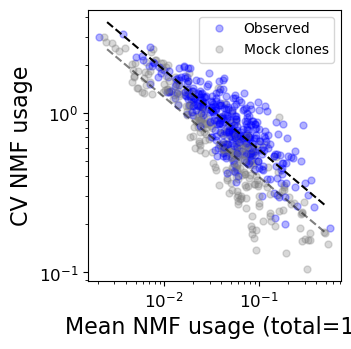

In [57]:
hp = importlib.reload(hp)

# Create plot of CV vs mean, and fano vs mean, with real and randomized data
fig, ax = hp.plot_NMF_mean_cv_relationship(
    mean_W, cv_W, 
    rnd_mean_W, rnd_cv_W, 
    real_fit, rnd_fit
)

if cell_type == 'k562':
    ax.set_ylim(0.07,10)

ax = plt.gca()  # Get current axes
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

hp.save_figure_rasterized_data(fig, 
    f'./figures/NMF_CV_fano/fig_NMF_usage_all_CV_mean_{cell_type}.pdf', dpi=300)
plt.show()

In [58]:
# Correct randomized CVs to match the change in mean relative to the real data
ap = importlib.reload(ap)
rnd_reg_cv_W, rnd_reg_mean_W = ap.create_regressed_randomized_cv(mean_W, 
                    rnd_mean_W, rnd_cv_W)


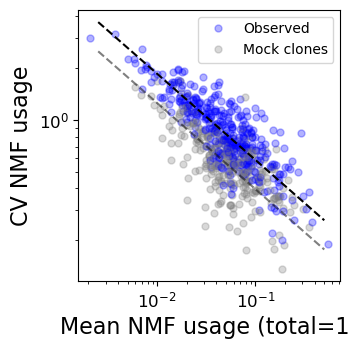

In [59]:
hp = importlib.reload(hp)

# Repeat plot of CV vs mean, and fano vs mean, 
# but now with real and regressed-randomized data

fig, ax = hp.plot_NMF_mean_cv_relationship(
    mean_W, cv_W,
    rnd_reg_mean_W, rnd_reg_cv_W,
    real_fit, rnd_fit
)

if cell_type == 'k562':
    ax.set_ylim(0.05,10)

ax = plt.gca()  # Get current axes
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

hp.save_figure_rasterized_data(fig, 
    f'./figures/NMF_CV_fano/fig_NMF_usage_all_CV_mean_rnd_regressed_{cell_type}.pdf', dpi=300)
plt.show()

#### Distribution of colony CVs and Fano factors

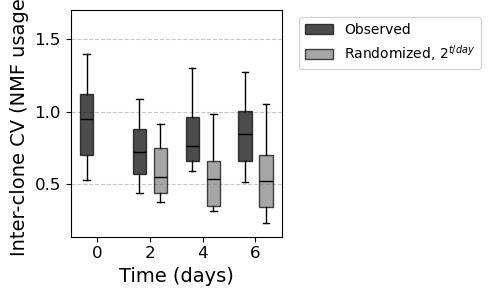

In [60]:
# Boxplots of observed vs mock clone CVs:
hp = importlib.reload(hp)
#hp.plot_program_boxplot_time_series(cv_W, 'Ctrl', ylabel='CV', figsize=(2, 3))
fig=hp.plot_program_boxplot_time_series({'Observed':cv_W['Ctrl'],r'Randomized, $2^{t/day}$':rnd_cv_W['Ctrl']}, ylabel='Inter-clone CV (NMF usage)', 
                                    figsize=(5.0, 3), 
                                    colors=['black','grey'], 
                                    box_width=0.5, group_spacing=1.3)


ax = plt.gca()  # Get current axes
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
# Save figure with editable font text:
hp.save_editable_pdf(fig, f'./figures/NMF_CV_fano/fig_nmf_cv_timeseries_ctrl_boxplot_{cell_type}.pdf', dpi=300)
plt.show()

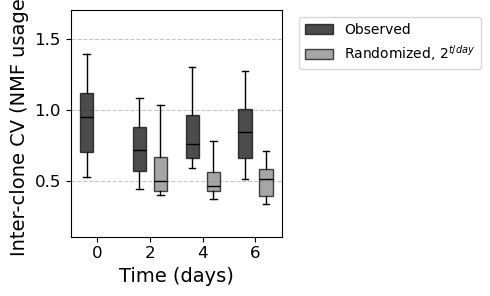

In [61]:
# Boxplots of observed vs mock clone CVs, with regressed randomized CVs:

hp = importlib.reload(hp)
#hp.plot_program_boxplot_time_series(cv_W, 'Ctrl', ylabel='CV', figsize=(2, 3))
hp.plot_program_boxplot_time_series({'Observed':cv_W['Ctrl'],r'Randomized, $2^{t/day}$':rnd_reg_cv_W['Ctrl']}, ylabel='Inter-clone CV (NMF usage)', 
                                    figsize=(5.0, 3), 
                                    colors=['black','grey'], 
                                    box_width=0.5, group_spacing=1.3)

ax = plt.gca()  # Get current axes
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_ylabel(ax.get_ylabel(), fontsize=14)
hp.save_editable_pdf(fig, 
        f'./figures/NMF_CV_fano/fig_nmf_cv_vs_rnd_regressed_timeseries_ctrl_boxplot_{cell_type}_Ctrl.pdf')
plt.show()

#### CV ratio timecourse

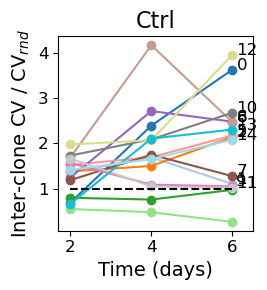

In [ ]:
# hp = importlib.reload(hp)

# # Plot individual conditions
# conditions = ['Ctrl'] #, 'Vor', 'Aza', 'Dec']

# for condition in conditions:
#     fig, ax = hp.plot_cv_ratio_timecourse(
#         cv_W[condition], 
#         rnd_cv_W[condition],
#         title=condition,
#         ylabel=r'Inter-clone CV / CV$_{rnd}$'
#     )

#     plt.savefig(f'./figures/NMF_CV_fano/fig_nmf_cv_vs_rnd_timeseries_{cell_type}_{condition}.pdf')

#     plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Rank plot of CV/CV_rnd averaged over days 4-6:
# condition = 'Ctrl'
# y = np.log2((cv_W[condition].loc[avg_timepoints, :] / rnd_cv_W[condition].loc[avg_timepoints, :]).mean(axis=0))

# # Sort values in descending order
# y_sorted = y.sort_values(ascending=False)

# # Create figure and axis
# fig, ax = plt.subplots(figsize=(3, 3))

# # Plot all values
# ax.plot(np.arange(len(y_sorted)) + 1, y_sorted, 'ko-', label='CV/CV_rnd')

# # Add horizontal line at y=0
# ax.axhline(0, color='k', linestyle='--', linewidth=0.8)

# # Add labels for factors with abs(y) > 1
# mask = y_sorted > 1

# # Correctly enumerate rank positions for the mask
# for rank, (factor, value) in enumerate(y_sorted.items(), start=1):
#     if np.abs(value) > 1:
#         va = 'bottom' if value > 0 else 'top'  # Adjust label placement
#         ax.text(rank+0.2*np.sign(value), value+0.1, f'{factor}', ha='center', va=va, fontsize=8)

# # Set axis labels
# ax.set_xlabel('Program rank', fontsize=14)
# ax.set_ylabel(r'log$_{2}$(CV/CV$_{\text{rnd}}$)' + '\n(days 4-6)', fontsize=14)

# # Add tight layout for better spacing
# plt.tight_layout()

# # Uncomment below to save the plot
# ax = plt.gca()  # Get current axes
# ax.tick_params(axis='both', labelsize=12)
# ax.set_xlabel(ax.get_xlabel(), fontsize=14)
# ax.set_ylabel(ax.get_ylabel(), fontsize=14)
# hp.save_editable_pdf(fig, 
#         f'./figures/NMF_CV_fano/fig_nmf_cv_vs_rnd_rank_days4-6_{cell_type}_Ctrl.pdf')


# plt.show()


NameError: name 'avg_timepoints' is not defined

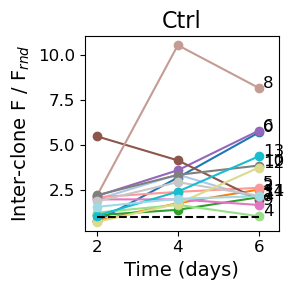

In [ ]:
# hp = importlib.reload(hp)

# # Plot individual conditions
# conditions = ['Ctrl'] #, 'Vor', 'Aza', 'Dec']

# for condition in conditions:
#     fig, ax = hp.plot_cv_ratio_timecourse(
#         fano_W[condition], 
#         rnd_cv_W[condition]**2 * rnd_mean_W[condition],
#         title=condition,
#         ylabel=r'Inter-clone F / F$_{rnd}$'
#     )

#     plt.savefig(f'./figures/NMF_CV_fano/fig_nmf_fano_vs_rnd_timeseries_{cell_type}_{condition}.pdf')

#     plt.show()

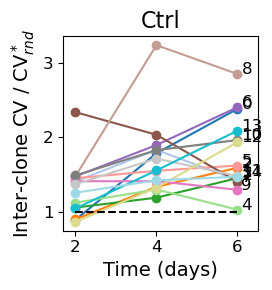

In [ ]:
# # Repeat with regressed randomized CVs:
# hp = importlib.reload(hp)

# # Plot individual conditions
# conditions = ['Ctrl'] #, 'Vor', 'Aza', 'Dec']

# for condition in conditions:
#     fig, ax = hp.plot_cv_ratio_timecourse(
#         cv_W[condition], 
#         rnd_reg_cv_W[condition],
#         title=condition,
#         ylabel=r'Inter-clone CV / CV$^*_{rnd}$'
#     )
#     plt.savefig(f'./figures/NMF_CV_fano/fig_nmf_cv_vs_rnd_regressed_timeseries_{cell_type}_{condition}.pdf')
#     plt.show()

In [ ]:
# # Top 5 variable programs above random:
# conds=['Ctrl','Vor', 'Aza','Dec']
# avg_timepoints = [4,6]
# ratio2rnd = {}

# for k,c in enumerate(conds):
#     ratio2rnd[c] = cv_W[c].loc[avg_timepoints,:].mean(axis=0)/rnd_cv_W[c].loc[avg_timepoints,:].mean(axis=0)
#     print(f'Condition: {c} -- Top 5 variable programs above random')
#     top5 = ratio2rnd[c][ratio2rnd[c]>1.0].sort_values(ascending=False).head(5)
#     print(top5)

Condition: Ctrl -- Top 5 variable programs above random
8     3.377774
0     2.907287
12    2.884468
6     2.601382
10    2.399638
dtype: float64
Condition: Vor -- Top 5 variable programs above random
12    9.077734
10    3.554234
14    2.977745
5     2.930746
9     2.434495
dtype: float64
Condition: Aza -- Top 5 variable programs above random
12    4.179130
10    2.893041
5     2.324664
9     1.802161
14    1.614776
dtype: float64
Condition: Dec -- Top 5 variable programs above random
12    6.536051
11    2.310100
2     2.277782
10    1.967870
14    1.535472
dtype: float64


In [ ]:
# # Top 5 variable programs above random, with regressed randomized CVs:
# conds=['Ctrl','Vor', 'Aza','Dec']
# avg_timepoints = [4,6]
# ratio2rnd = {}

# for k,c in enumerate(conds):
#     ratio2rnd[c] = cv_W[c].loc[avg_timepoints,:].mean(axis=0)/rnd_reg_cv_W[c].loc[avg_timepoints,:].mean(axis=0)
#     print(f'Condition: {c} -- Top 5 variable programs above random')
#     top5 = ratio2rnd[c][ratio2rnd[c]>1.0].sort_values(ascending=False).head(5)
#     print(top5)

Condition: Ctrl -- Top 5 variable programs above random
8     3.100519
6     2.104274
0     2.054559
10    1.907002
13    1.780809
dtype: float64
Condition: Vor -- Top 5 variable programs above random
6     2.734226
12    2.447963
9     2.382737
3     1.997898
7     1.975238
dtype: float64
Condition: Aza -- Top 5 variable programs above random
12    1.795455
8     1.659768
10    1.654860
5     1.573019
9     1.556942
dtype: float64
Condition: Dec -- Top 5 variable programs above random
12    2.126127
11    1.789674
2     1.736973
7     1.528969
8     1.504388
dtype: float64


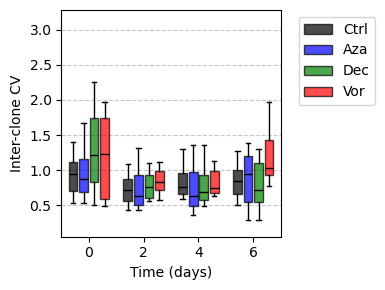

In [68]:
# Plot multiple conditions for one program
hp = importlib.reload(hp)
hp.plot_program_boxplot_time_series({'Ctrl':cv_W['Ctrl'],'Aza':cv_W['Aza'],'Dec':cv_W['Dec'],'Vor':cv_W['Vor']}, ylabel='Inter-clone CV', 
                                    figsize=(4.0, 3), 
                                    colors=['black','blue','green','red'], 
                                    box_width=0.32, group_spacing=1.15)
plt.savefig(f'./figures/NMF_CV_fano/fig_nmf_cv_timeseries_cond_boxplot_{cell_type}.pdf')
plt.show()

/var/folders/rv/y54x08qj7wqb3c4s6_wk8c7w0000gr/T/ipykernel_81292/2587591943.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', len(cv_W['Ctrl'].columns))


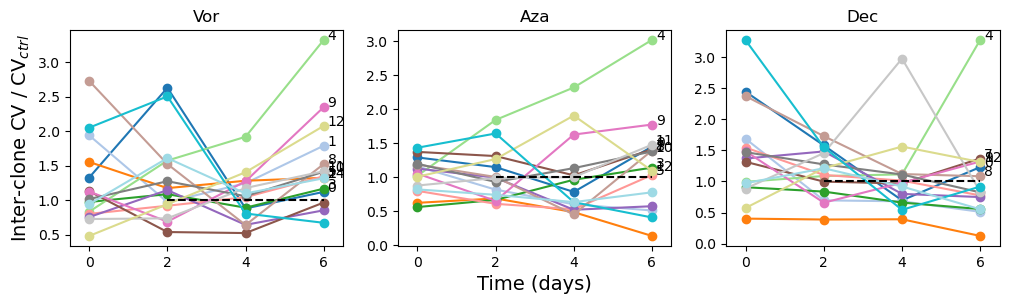

In [ ]:
# from matplotlib.cm import get_cmap

# timepoints = [2, 4, 6]
# fig, ax = plt.subplots(1,3,figsize=(12,2.8))
# # Generate a colormap with n_lines unique colors
# cmap = get_cmap('tab20', len(cv_W['Ctrl'].columns))

# conds=['Vor', 'Aza','Dec']
# ctrl_dict={'Vor':'Ctrl','Aza':'Ctrl','Dec':'Ctrl'}

# for k,c in enumerate(conds):
#     for i,f in enumerate(cv_W['Ctrl'].columns):
#         #plt.plot(cv_W['Ctrl'].loc[t,:],rnd_cv_W['Ctrl'].loc[t,:],'o',label=f'day {t}')
#         y = list(cv_W[c].loc[:,f]/cv_W[ctrl_dict[c]].loc[:,f])
#         ax[k].plot([0, 2, 4, 6],y,'o-',label=f'factor {f}',color=cmap(i))
#         if y[-1]>1.0:
#             ax[k].text(6.1,y[-1],f)
#     ax[k].plot([2,6],[1,1],'k--')
#     ax[k].set_title(c)
#     if(k==1):
#         ax[k].set_xlabel('Time (days)',fontsize=14)
#     if k==0:
#         ax[k].set_ylabel(r'Inter-clone CV / CV$_{ctrl}$',fontsize=14)
#     ax[k].set_xlim(-0.5,6.5)
# #plt.legend(bbox_to_anchor=(1, 1))



/var/folders/rv/y54x08qj7wqb3c4s6_wk8c7w0000gr/T/ipykernel_81292/3299501019.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20', len(fano_W['Ctrl'].columns))


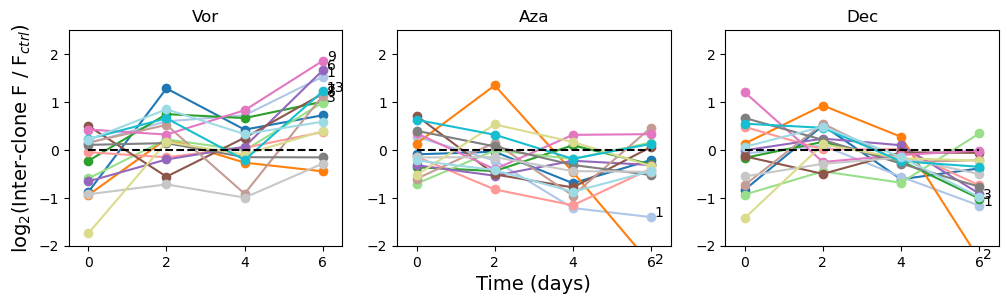

In [ ]:
# from matplotlib.cm import get_cmap

# timepoints = [2, 4, 6]
# fig, ax = plt.subplots(1,3,figsize=(12,2.8))
# # Generate a colormap with n_lines unique colors
# cmap = get_cmap('tab20', len(fano_W['Ctrl'].columns))

# conds=['Vor', 'Aza','Dec']
# ctrl_dict={'Vor':'Ctrl','Aza':'Ctrl','Dec':'Ctrl'}

# for k,c in enumerate(conds):
#     for i,f in enumerate(fano_W['Ctrl'].columns):
#         #plt.plot(cv_W['Ctrl'].loc[t,:],rnd_cv_W['Ctrl'].loc[t,:],'o',label=f'day {t}')
#         y = list(np.log2(fano_W[c].loc[:,f]/fano_W[ctrl_dict[c]].loc[:,f]))
#         ax[k].plot([0, 2, 4, 6],y,'o-',label=f'factor {f}',color=cmap(i))
#         if np.abs(y[-1])>1.0:
#             ax[k].text(6.1,y[-1],f)
#     ax[k].plot([0,6],[0,0],'k--')
#     ax[k].set_title(c)
#     if(k==1):
#         ax[k].set_xlabel('Time (days)',fontsize=14)
#     if k==0:
#         ax[k].set_ylabel(r'log$_{2}$(Inter-clone F / F$_{ctrl}$)',fontsize=14)
#     ax[k].set_xlim(-0.5,6.5)
#     ax[k].set_ylim(-2,2.5)

# plt.savefig(f'./figures/NMF_CV_fano/fig_nmf_fano_timeseries_drugs_{cell_type}.pdf')


### Heatmaps of NMF dynamics

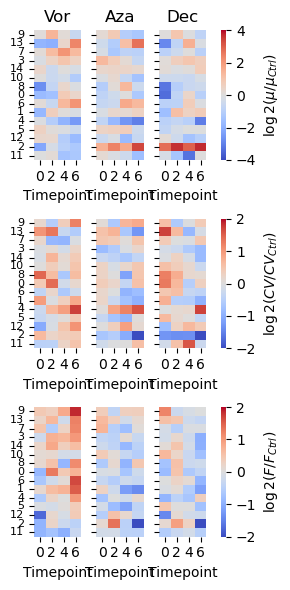

In [71]:

hp = importlib.reload(hp)
sort_var='fano'
fig = hp.create_nmf_dynamics_control_normalized_heatmap_grid(mean_W, cv_W,fano_W, sort_by=sort_var,  figsize=(3,6))


# save the figure:
hp.save_figure_rasterized_data(fig, 
    f'./figures/NMF_CV_fano/fig_NMF_m_CV_F_heatmaps_Ctrl_normalized_sorted_by_{sort_var}_{cell_type}.pdf', dpi=300)

plt.show()

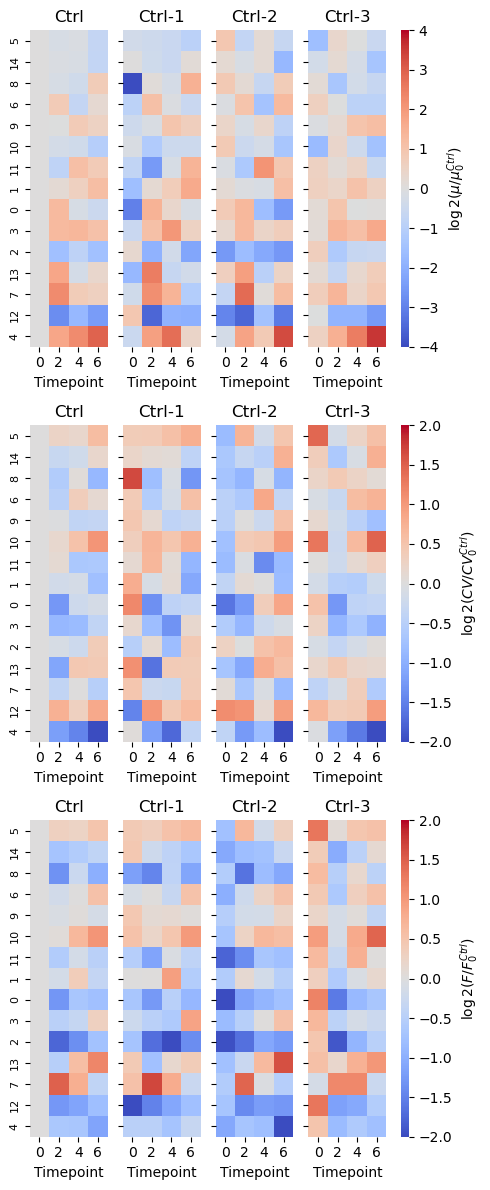

In [72]:
# Example usage
hp = importlib.reload(hp)
fig = hp.create_nmf_dynamics_heatmap_grid(mean_W, cv_W,fano_W, figsize=(5,12),conditions=['Ctrl','Ctrl-1','Ctrl-2','Ctrl-3'])


# To save the figure:
hp.save_figure_rasterized_data(fig, f'./figures/NMF_CV_fano/fig_NMF_median_CV_Fano_heatmaps_{cell_type}_controls.pdf', dpi=300)
#fig.savefig(, dpi=300, bbox_inches='tight')
plt.show()

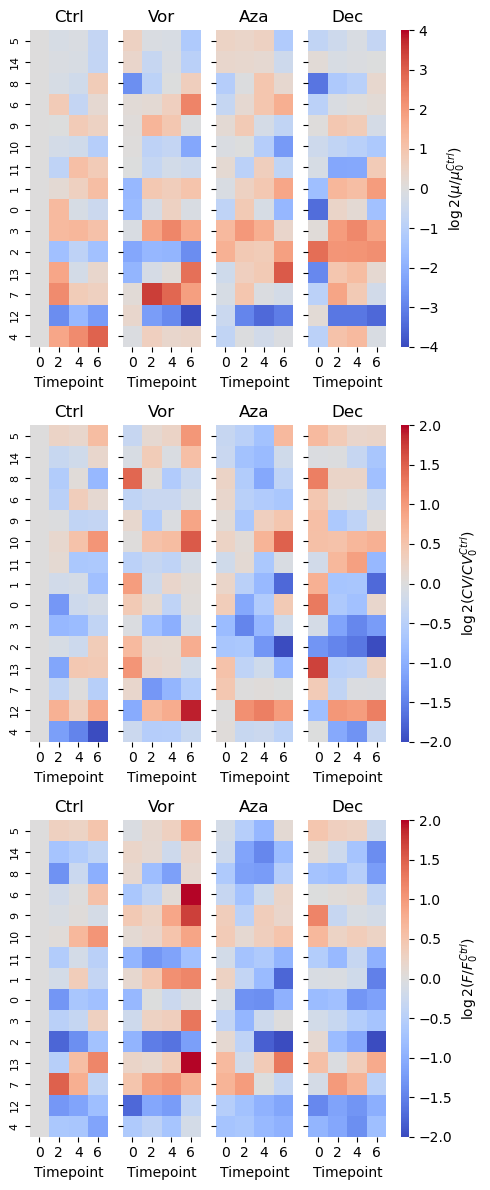

In [73]:
# Example usage
hp = importlib.reload(hp)
fig = hp.create_nmf_dynamics_heatmap_grid(mean_W, cv_W,fano_W, figsize=(5,12),conditions=None)


# To save the figure:
hp.save_figure_rasterized_data(fig, f'./figures/NMF_CV_fano/fig_NMF_mean_CV_Fano_heatmaps_{cell_type}.pdf', dpi=300)
#fig.savefig(, dpi=300, bbox_inches='tight')
plt.show()

# SAVE AND RELOAD TASKS

In [12]:
import pickle
import os
import torch
save_dir = f'./saved_workspaces/'
save_file = f'workspace_{cell_type}.pkl'

#### Save:

In [18]:


do_save = True # This is off to avoid overwriting the workspace unless you want to

if do_save:
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Save the regular workspace objects
    workspace = {
        # AnnData objects
        'ad_all': ad_all,
        'ad_colonies': ad_colonies, 
        'ad_sc': ad_sc,
        'ad_colonies_rand': ad_colonies_rand,
        
        # Additional variables
        #'importance_dict': importance_dict,
        #'corr': corr,
        #'metrics': metrics,
        #'pred_ctrl': pred_ctrl,
        #'imp_dict_ctrl': imp_dict_ctrl, 
        #'corr_ctrl': corr_ctrl,
        #'metrics_ctrl': metrics_ctrl
    }

    # Save main workspace
    save_path = os.path.join(save_dir, save_file)
    with open(save_path, 'wb') as f:
        pickle.dump(workspace, f)
    
    #  # Save models separately using torch.save
    # model_save_path = os.path.join(save_dir, f'trained_model_{cell_type}.pt')
    # model_ctrl_save_path = os.path.join(save_dir, f'trained_model_ctrl_{cell_type}.pt')
    
    # torch.save(trained_model.state_dict(), model_save_path)
    # torch.save(trained_model_ctrl.state_dict(), model_ctrl_save_path)
        
    print(f"Workspace and models saved to {save_dir}")

Workspace and models saved to ./saved_workspaces/


In [9]:
# Save normalized NMF usage dataframe
nmf_usage_file_path = f'./MCMC_data/data_NMF_usage_{cell_type}.csv'

# Create a new DataFrame instead of a view
nmf_df = ad_all.obs[['timepoint','condition','condition_orig']].copy()

# Normalize NMF values
x = ad_all.obsm['X_nmf']/ad_all.obsm['X_nmf'].sum(axis=1,keepdims=True)

# Add NMF columns using loc
for i in range(ad_all.obsm['X_nmf'].shape[1]):
    nmf_df.loc[:, f'NMF_{i}'] = x[:,i]

# Save to CSV
nmf_df.to_csv(nmf_usage_file_path)

#### Reload:

In [50]:
do_reload = True  # Set to True to reload the workspace
save_file = f'workspace_{cell_type}.pkl'

if do_reload:
    # Load main workspace
    save_path = os.path.join(save_dir, save_file)
    with open(save_path, 'rb') as f:
        workspace = pickle.load(f)

    # Restore variables from workspace
    ad_all = workspace['ad_all']
    ad_colonies = workspace['ad_colonies']
    ad_sc = workspace['ad_sc']
    ad_colonies_rand = workspace['ad_colonies_rand']
    importance_dict = workspace['importance_dict']
    corr = workspace['corr']
    metrics = workspace['metrics']
    pred_ctrl = workspace['pred_ctrl']
    imp_dict_ctrl = workspace['imp_dict_ctrl']
    corr_ctrl = workspace['corr_ctrl']
    metrics_ctrl = workspace['metrics_ctrl']

    # Load models
    class Predictor(torch.nn.Module):
        def __init__(self, input_size=15):  # Set default input_size to 15 as shown in the architecture
            super().__init__()
            self.features = torch.nn.Sequential(
                torch.nn.Linear(input_size, 32),
                torch.nn.ReLU()
            )
            self.output = torch.nn.Linear(32, 1)
            
        def forward(self, x):
            x = self.features(x)
            return self.output(x)
    
    # Create new model instances with input_size=15
    trained_model = Predictor(input_size=15)
    trained_model_ctrl = Predictor(input_size=15)
    
    # Load saved weights
    model_save_path = os.path.join(save_dir, f'trained_model_{cell_type}.pt')
    model_ctrl_save_path = os.path.join(save_dir, f'trained_model_ctrl_{cell_type}.pt')
    
    trained_model.load_state_dict(torch.load(model_save_path))
    trained_model_ctrl.load_state_dict(torch.load(model_ctrl_save_path))
    
    # Set models to evaluation mode
    trained_model.eval()
    trained_model_ctrl.eval()

    print("Workspace and models loaded successfully")

KeyError: 'importance_dict'

### Save NMF factors to excel file (Table S2)

In [52]:
H_raw=ad_all.uns['nmf']['components']
nmf_genes = ad_all.uns['nmf']['highly_variable_genes']
gene_names = nmf_genes
gene_names = [gene[:-3] if gene.endswith('_mm') else gene for gene in gene_names]
gene_names = [gene[:-3] if gene.endswith('_hg') else gene for gene in gene_names]
# Reweight by non-zero mean expression:
nonzero_means = ad_all.var.loc[ad_all.var.highly_variable, 'mean_nonzero'].values  # Add .values
H = H_raw / nonzero_means[None, :] 
#H_norm = H_weighted / (H_weighted.sum(axis=0) + 1e-10)
# Create a boolean mask for non-mitochondrial genes
do_filter_genes = True
if do_filter_genes:
    exclude_prefixes = pd.read_csv(exclude_prefix_file, header=None)[0].tolist()
    exclude_suffixes = ['Rik']
    mask = ~np.array([any(gene.startswith(p) for p in exclude_prefixes)
                      for gene in gene_names])
    mask = mask & ~np.array([any(gene.endswith(p) for p in exclude_suffixes)
                      for gene in gene_names])
    # Apply the mask to both the array and gene list
    H = H[:,mask]
    gene_names = np.array(gene_names)[mask]


n=ad_colonies.uns['nmf']['n_components']
H = H/H.max(axis=1,keepdims=True) # Col-normalize to the gene with highest contribution


# Create a DataFrame from the NMF components
H_df = pd.DataFrame(H.T, 
                    columns=[f'Factor_{i}' for i in range(H.shape[0])],
                    index=gene_names)

# Create a DataFrame from the NMF components
H_raw_df = pd.DataFrame(H_raw.T, 
                    columns=[f'Factor_{i}' for i in range(H_raw.shape[0])],
                    index=nmf_genes)

# Save to Excel
H_df.to_excel(f'NMF_factors_{cell_type}.xlsx', index=True)
H_raw_df.to_excel(f'NMF_factors_raw_{cell_type}.xlsx', index=True)
H_raw_df.to_csv(f'NMF_factors_raw_{cell_type}.csv', index=True)
